In [2]:
## Helper function. Please do not change the code.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.vq import kmeans2
from sklearn.datasets import make_blobs

def plot_kmeans_init_projs(X, C=None, a=None, k=9, custom_title=None, show_legend=False, point_size=1):
    unique_colors = list(mcolors.CSS4_COLORS.keys())
    color_start = 9

    if a is not None:
        assert X.shape[0] == a.shape[0], 'X and a should have the same number of elements.'
        chosen_colors = unique_colors[color_start : color_start + k]
        for cluster_idx in range(k):
            color = chosen_colors[cluster_idx]
            plt.scatter(X[a == cluster_idx, 0], X[a == cluster_idx, 1], color=color, marker='o', s=point_size, label=f'Cluster {cluster_idx+1}')
    else:
        plt.scatter(X[:, 0], X[:, 1], color='blue', marker='o', s=point_size)

    if C is not None:
        if a is None:
            chosen_colors = unique_colors[color_start : color_start + k]
        for cluster_idx in range(k):
            color = chosen_colors[cluster_idx]
            plt.scatter(C[cluster_idx, 0], C[cluster_idx, 1], color=color, marker='+', s=1000)

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')

    if custom_title is not None:
        plt.title(custom_title)

    if show_legend:
        plt.legend()

    plt.show()


zsh:1: command not found: gdown


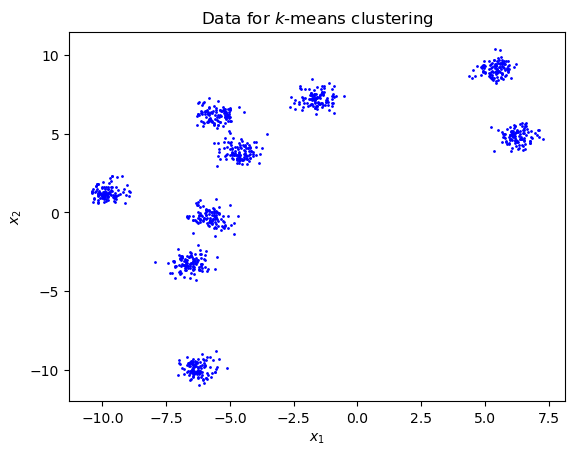

In [3]:
## Do not change code. Here we download and visualize the dataset.

!gdown 1XIJCGjfPWhp328jx5qhfJcIj0D9q50Lo

import pickle

data_for_kmean = pickle.load(open('data_for_kmeans.pkl', 'rb'))

plot_kmeans_init_projs(X=data_for_kmean['datapoints_X'], custom_title='Data for $k$-means clustering')

In [6]:
## Complete the code marked as "TODO".
"""
Definitions of the parameters in this cell:
    X : ndarray of shape (n_samples, n_features)
        The data points.
    C : ndarray of shape (k, n_features)
        The centroids.
    a : ndarray of shape (n_samples,)
        The cluster assignments (each element is an integer representing a centroid index).
"""


def update_assignments(X, C):
    """
    Compute the matrix of all pairwise distances between rows of X and C,
    and assign each point in X to the closest centroid in C.
    """
    n = X.shape[0]
    k = C.shape[0]

    D = np.zeros((n, k))  # D will contain the distance between each point and each centroid

    for i in range(k):
        ## TODO: fill in the values in D.
        # Euclidean distance between each point in X and the i-th centroid in C
        D[:, i] = np.sum((X - C[i])**2, axis=1)

    ## TODO: take argmax over the distance matrix along the last dimension to find the assignment
    # index of the closest centroid for each point
    a = np.argmin(D, axis=1)

    return a

def update_centers(X, C, a):
    """
    Update the cluster centroids by computing the mean of all points assigned to each centroid.
    """
    k = C.shape[0]

    ## NOTE: We will update the centroids of only the "non-empty" clusters. If a cluster is empty, we will simply keep the previous centroid.
    for i in range(k):
        ## TODO: take all the points from X where a == i
        points = X[a == i]
        ## TODO: if "points" is not empty, update the centroids C[i, :].
        if len(points) > 0:
            C[i, :] = np.mean(points, axis=0)

    return C

def lloyd_iteration(X, C0, verbose=0, num_iter=None):
    """
    Perform Lloyd's algorithm iterations until convergence.
    Verbose (Optional. Provided as a helper element):
        Set verbose=1 if you want to print kmeans_obj after each step.
        Set verbose=2 if you want to print kmeans_obj and plot the clustering after each step.
    """
    C = C0
    a = np.zeros(X.shape[0], dtype=int) # We will keep updating this vector.
    iter = 0
    obj_vals = []
    while True:
        ## TODO: Compute the new assignments a_new
        a_new = update_assignments(X, C)

        if verbose in {1, 2}:
            obj_vals += [kmeans_obj(X=X, C=C, a=a_new)]
            print('iter =', iter, '|\tkmeans_obj =', obj_vals[-1])
        if verbose in {2}:
            plot_kmeans_init_projs(X=X, C=C, a=a_new)


        if num_iter is not None:
            if iter >= num_iter:
                if verbose in {1, 2}:
                    print('maximum iter reached')
                return C, a_new

        ## TODO: Implement the loop termination condition: If assignments haven't changed, break the loop.
        if np.array_equal(a, a_new):
            break

        ## TODO: Update the centroids C
        C = update_centers(X, C, a_new)

        a = a_new

        iter += 1

    if verbose in {1, 2}:
        print('Number of iterations until Lloyd’s method converges:', iter)

        plt.xlabel('Number of iterations')
        plt.ylabel('Values of k-means objective function')
        plt.plot(np.arange(1, len(obj_vals)), obj_vals[1:])
        plt.show()

    return C, a


def kmeans_obj(X, C, a):
    """
    Computes the K-means objective function.
    """

    k = C.shape[0]  # Number of clusters

    ## TODO: compute the k-means objective "obj"
    obj = 0
    for i in range(k):
        # Extract points assigned to cluster i
        cluster_points = X[a == i]
        # squared distances between points and the cluster centroid
        distances = np.linalg.norm(cluster_points - C[i], axis=1)**2
        
        obj += np.sum(distances)

    return obj

In [7]:
## Helper function. Please do not change the code.

def kmeans_cluster(X, k=9, init='random', num_restarts=20, verbose=0):
    assert init in {'fixed', 'random', 'kmeans++'}, '"init" should be in {"fixed", "random", "kmeans++"}'

    best_obj_val = np.inf
    best_C = None
    best_a = None

    for i in range(num_restarts):
        if init == 'fixed':
            C0 = np.array([[ -3.8013922 ,   4.18036784],
                            [  6.38437091, -10.4922861 ],
                            [  2.51777316,   9.76860684],
                            [  0.16063288,   6.83472497],
                            [ -7.66447399,  -6.39978007],
                            [ -7.66490039,  -7.05102549],
                            [ -9.3957959 ,  -7.01731424],
                            [  4.88988245,  -4.43834555],
                            [  0.20406004,   0.26795912]])

            assert C0.shape[0] == k

            C, a = lloyd_iteration(X=X, C0=C0, verbose=1)
            obj_val = kmeans_obj(X, C, a)

        elif init == 'random':
            samples_x1 = np.random.uniform(X[:, 0].min(), X[:, 0].max(), k)
            samples_x2 = np.random.uniform(X[:, 1].min(), X[:, 1].max(), k)
            C0 = np.stack([samples_x1, samples_x2]).T
            C, a = lloyd_iteration(X=X, C0=C0, verbose=0)
        else:
            C, a = kmeans2(data=X, k=k, minit='++', iter=10)

        obj_val = kmeans_obj(X, C, a)

        if obj_val < best_obj_val:
            best_obj_val = obj_val
            best_C = C
            best_a = a
            if verbose == 1:
                print('restart number:', i, '|\tobj_val =', obj_val)
                plot_kmeans_init_projs(X, C, a)

    return best_C, best_a, best_obj_val

iter = 0 |	kmeans_obj = 16776.26222006756
iter = 1 |	kmeans_obj = 5100.615068223845
iter = 2 |	kmeans_obj = 4405.369431421426
iter = 3 |	kmeans_obj = 4189.251659076012
iter = 4 |	kmeans_obj = 2897.3515939779622
iter = 5 |	kmeans_obj = 2740.603719169353
iter = 6 |	kmeans_obj = 2708.166919314438
iter = 7 |	kmeans_obj = 2640.011745833185
iter = 8 |	kmeans_obj = 2423.3702733442965
iter = 9 |	kmeans_obj = 2239.8078156770357
iter = 10 |	kmeans_obj = 2236.4308600677223
Number of iterations until Lloyd’s method converges: 10


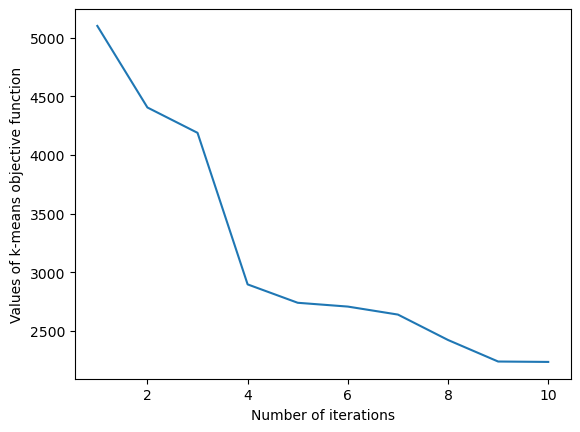

restart number: 0 |	obj_val = 2236.4308600677223


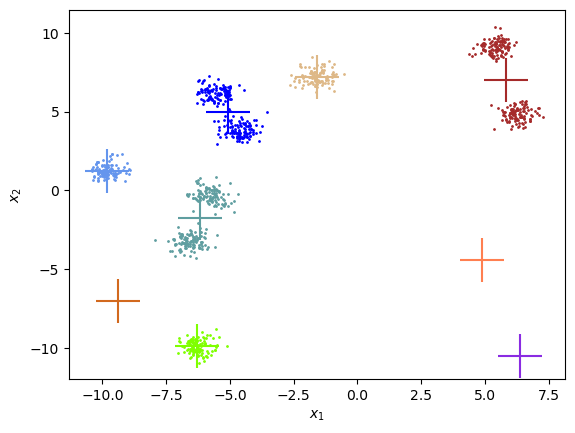

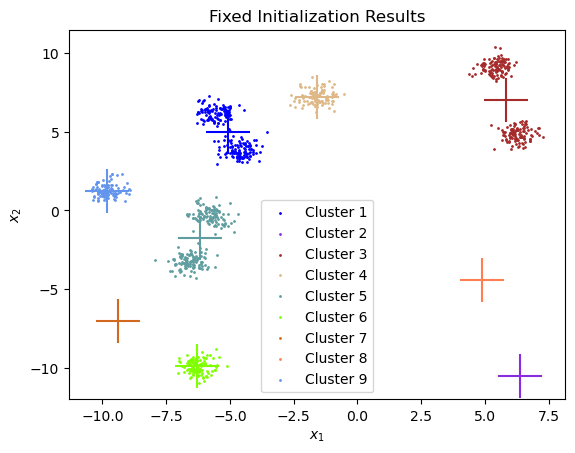

With fixed:	kmeans obj = 2236.4308600677223


In [8]:
## Complete the code (marked as "TODO") to generate the results for Section 2.2
X = data_for_kmean['datapoints_X']

## You must use the following arguments for the "kmeans_cluster" function
k = 9 ## k = number of clusters
num_restarts = 1 ## num_restarts = number of restarts
init='fixed' ## init = initialization approach

## TODO: Use the function "kmeans_cluster" to generate results for question 1, 2, 3, and 4 under Section 2.2. Note that if we set init='fixed', this function will automatically generate the plot for question 4.
C, a, obj_val = kmeans_cluster(X, k=k, init=init, num_restarts=num_restarts, verbose=1)
print('\n\n')

## TODO: Use the function "plot_kmeans_init_projs" to generate the plot for question 5 under Section 2.2
plot_kmeans_init_projs(X, C, a, k=k, custom_title="Fixed Initialization Results", show_legend=True)
print(f'With fixed:\tkmeans obj = {obj_val}')

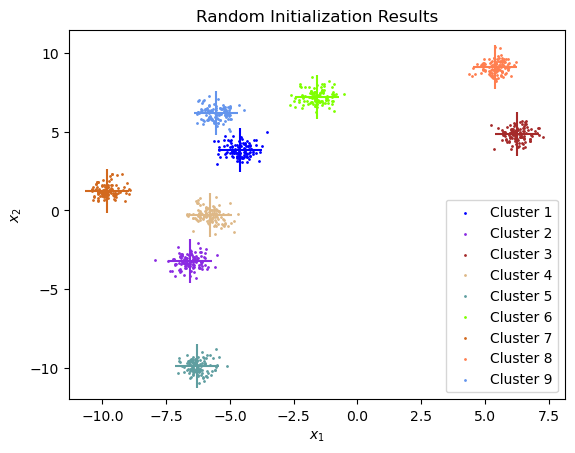

With random:	kmeans obj = 319.3014972748898



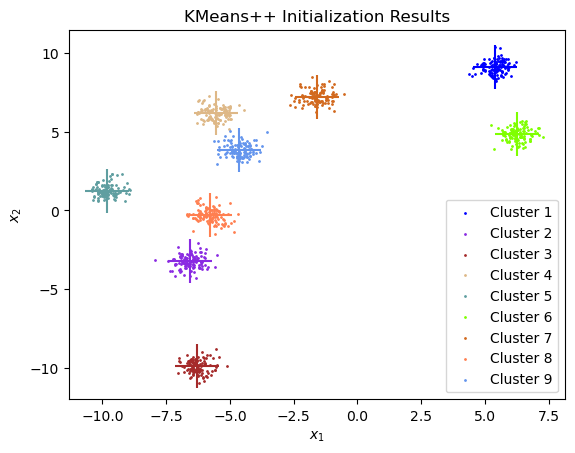

With kmeans++:	kmeans obj = 319.30079435753146


In [9]:
## Complete the code below (marked as "TODO") to generate the plot for Section 2.3.1.

np.random.seed(42)  ## Please do not change the seed

X = data_for_kmean['datapoints_X']

## You must use the following arguments for the "kmeans_cluster" function
k = 9 ## k = number of clusters
num_restarts = 10 ## num_restarts = number of restarts

### TODO: run kmeans_cluster to generate results for init='random'
C, a, obj_val = kmeans_cluster(X, k=k, init='random', num_restarts=num_restarts, verbose=0)

## TODO: plot projections for random init
plot_kmeans_init_projs(X, C, a, k=k, custom_title="Random Initialization Results", show_legend=True)
print(f'With random:\tkmeans obj = {obj_val}')
print()


### TODO: run kmeans_cluster to generate results for init='kmeans++'
C, a, obj_val = kmeans_cluster(X, k=k, init='kmeans++', num_restarts=num_restarts, verbose=0)

## TODO: plot projections for kmeans++ init
plot_kmeans_init_projs(X, C, a, k=k, custom_title="KMeans++ Initialization Results", show_legend=True)
print(f'With kmeans++:\tkmeans obj = {obj_val}')

In [10]:
## Complete the code below (marked as "TODO") to generate the plot for Section 2.3.2.
"""
Note:
For each value of init in {'random', 'kmeans++'}, report the mean and standard deviation
of the k-means objective value returned by kmeans_cluster(X, 9, init, 1) over 1000 runs.
"""

np.random.seed(42)  ## Please do not change the seed

## You must use the following arguments for the "kmeans_cluster" function
k = 9 ## k = number of clusters
num_restarts = 1 ## num_restarts = number of restarts


num_runs = 1000
for init in ['random', 'kmeans++']:
    obj_vals = []

    ## TODO: run kmeans_cluster "num_runs" times, store the k-means objective values.
    for _ in range(num_runs):
        _, _, obj_val = kmeans_cluster(X, k=k, init=init, num_restarts=num_restarts, verbose=0)
        obj_vals.append(obj_val)


    ## TODO: Compute the mean and standard deviation of the k-means objective values.
    mean_obj = np.mean(obj_vals)
    std_obj = np.std(obj_vals)

    print(f"Initialization: {init}")
    print(f"Mean Objective: {mean_obj:.2f}")
    print(f"Standard Deviation: {std_obj:.2f}")
    print()

Initialization: random
Mean Objective: 2402.46
Standard Deviation: 1137.72

Initialization: kmeans++
Mean Objective: 539.70
Standard Deviation: 283.26

